#**Informe de Inteligencia de Negocio: Venture Capital en el Sector Biomédico**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('startups_dataset.csv')
df.head()

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


# Ejercicio 1: Diagnóstico Inicial del Dataset
En este primer paso, cargamos los datos brutos de Crunchbase para ver a qué nos enfrentamos. Revisamos el volumen total de registros (más de 66.000 empresas) y comprobamos cuántos valores nulos hay. Este diagnóstico inicial nos sirve para definir nuestra estrategia de limpieza sin perder información vital.

In [ ]:
df = pd.read_csv('startups_dataset.csv')

print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")

print("--- TIPOS DE DATOS ---")
print(df.dtypes)
print("\n")

print("--- VOLUMEN DE VALORES NULOS POR COLUMNA ---")
nulos = df.isnull().sum()
print(nulos[nulos > 0].sort_values(ascending=False))

Dimensiones del dataset: 66368 filas y 14 columnas.

--- TIPOS DE DATOS ---
permalink            object
name                 object
homepage_url         object
category_list        object
funding_total_usd    object
status               object
country_code         object
state_code           object
region               object
city                 object
funding_rounds        int64
founded_at           object
first_funding_at     object
last_funding_at      object
dtype: object


--- VOLUMEN DE VALORES NULOS POR COLUMNA ---
founded_at          15221
state_code           8547
region               8030
city                 8028
country_code         6958
homepage_url         5058
category_list        3148
first_funding_at       24
name                    1
dtype: int64


Detectamos una volumetría masiva (más de 66.000 registros) y una presencia significativa de valores nulos en columnas clave. Esto nos confirma que un análisis estadístico a ciegas sería erróneo y justifica la necesidad de una limpieza profunda para garantizar la fiabilidad de nuestras métricas.

# 2. Limpieza de la Inversión y Rigor Estadístico
Hemos detectado que la columna `funding_total_usd` tiene guiones (`-`) cuando la inversión de una empresa es confidencial. Para no hundir artificialmente las medias asumiendo que levantaron 0 dólares, hemos decidido sustituir esos guiones por valores nulos reales (`NaN`). Así nos aseguramos de que nuestros cálculos financieros sean 100% rigurosos y solo para aquellas empresas que lo declararon.


In [ ]:
mascara_guiones = (df['funding_total_usd'] == '-')
df.loc[mascara_guiones, 'funding_total_usd'] = np.nan

df['funding_total_usd'] = df['funding_total_usd'].astype(float)

print("--- ESTADÍSTICA DE FINANCIACIÓN (declarada) ---")
print(df['funding_total_usd'].describe())

--- ESTADÍSTICA DE FINANCIACIÓN (declarada) ---
count    5.358300e+04
mean     1.847860e+07
std      1.880133e+08
min      1.000000e+00
25%      3.356235e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64


Al sustituir los guiones por nulos reales (`NaN`) en lugar de ceros, hemos protegido la integridad matemática del modelo. Si hubiéramos asumido ceros para las rondas confidenciales, la media real de inversión del mercado habría caído drásticamente, ofreciendo una visión distorsionada a los inversores.

# 3. Formateo de Series Temporales
Las fechas del dataset vienen originalmente en formato de texto, lo que nos impide hacer cálculos cronológicos. Aquí convertimos las columnas de fundación y de primera inversión al formato oficial `Datetime` de Pandas, preparándolas para analizar los tiempos de maduración del mercado más adelante.

In [ ]:
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'], errors='coerce')

print("Tipo de 'founded_at':", df['founded_at'].dtypes)
print("Tipo de 'first_funding_at':", df['first_funding_at'].dtypes)

Tipo de 'founded_at': datetime64[ns]
Tipo de 'first_funding_at': datetime64[ns]


La estandarización de las variables al formato `Datetime` es el cimiento para cualquier análisis longitudinal. Gracias a esto, hemos desbloqueado la capacidad de calcular intervalos de maduración de las startups y detectar patrones históricos que el texto plano mantenía ocultos.

# 4. Extracción del Nicho de Salud
Tras la limpieza general, debemos aislar nuestro objeto de estudio: la Ingeniería Biomédica y la Salud. Para evitar errores en el filtrado, primero rellenamos los valores nulos en la lista de categorías. Luego, combinamos múltiples máscaras booleanas utilizando el operador lógico OR (`|`) para capturar cualquier startup que contenga las etiquetas clave del sector, creando un subconjunto de datos exclusivo de alta calidad.

In [ ]:
df['category_list'] = df['category_list'].fillna('Desconocido')

mascara_bio = df['category_list'].str.contains('Biotechnology')
mascara_salud = df['category_list'].str.contains('Health Care')
mascara_medica = df['category_list'].str.contains('Medical')

df_salud = df[mascara_bio | mascara_salud | mascara_medica].copy()

print(df_salud.shape)

(7824, 14)


Tras aplicar los filtros lógicos, logramos reducir el ruido del dataset global aislando algo más de 7.000 empresas clave. Esto nos permite centrar el 100% de nuestra capacidad analítica en el ecosistema biomédico y de salud, eliminando las desviaciones generadas por sectores ajenos a nuestra investigación.

# 5. El Árbol de Sub-especialidades
Las startups biomédicas son complejas y suelen estar registradas bajo múltiples etiquetas simultáneamente. Para entender la diversidad de nuestro ecosistema, necesitamos extraer un catálogo único de disciplinas. Utilizaremos bucles `for` para recorrer las listas de categorías, separar los textos y almacenarlos en una estructura de datos de tipo `set`, garantizando que obtenemos valores únicos sin repeticiones.

In [ ]:
especialidades_unicas = set()
lista_categorias = df_salud['category_list'].tolist()

for fila in lista_categorias:
    elementos = fila.split('|')
    for especialidad in elementos:
        especialidades_unicas.add(especialidad)

print(len(especialidades_unicas))
print(list(especialidades_unicas)[:10])

434
['Clinical Trials', 'Data Integration', 'Bitcoin', 'Contact Management', 'FinTech', 'App Marketing', 'Virtual Worlds', 'Marketing Automation', 'SaaS', 'Entertainment']


El uso del conjunto (`set`) nos reveló que nuestro nicho de estudio está compuesto por más de 400 sub-disciplinas únicas. Esto demuestra que la tecnología de la salud no es un mercado cerrado, sino un ecosistema altamente fragmentado y multidisciplinar.

# 6. Análisis de Densidad y Competencia
Para saber dónde se mueve realmente el mercado, hemos programado un algoritmo basado en diccionarios que cuenta cuántas veces se repite cada especialidad. Esto nos permite extraer el "Top 5" de nichos más saturados y entender dónde hay más competencia.

In [ ]:
frecuencias_especialidades = {}
lista_categorias = df_salud['category_list'].tolist()

for fila in lista_categorias:
    elementos = fila.split('|')
    for especialidad in elementos:
        if especialidad in frecuencias_especialidades:
            frecuencias_especialidades[especialidad] = frecuencias_especialidades[especialidad] + 1
        else:
            frecuencias_especialidades[especialidad] = 1

serie_frecuencias = pd.Series(frecuencias_especialidades)
top_5_nichos = serie_frecuencias.sort_values(ascending=False).head(5)

print("--- TOP 5 NICHOS CON MÁS STARTUPS ---")
print(top_5_nichos)

--- TOP 5 NICHOS CON MÁS STARTUPS ---
Biotechnology          4562
Health Care            2385
Medical                1203
Health and Wellness     609
Medical Devices         566
dtype: int64


El algoritmo de conteo nos permitió identificar el "Top 5" de especialidades. Hemos constatado que áreas como la Biotecnología pura y el Software Médico concentran la gran mayoría de las fundaciones, señalando dónde existe el mayor apetito inversor y, a la vez, la mayor competencia.

# 7. Supervivencia y Estado Actual del Sector
Para evaluar el riesgo del capital riesgo en biomedicina, hemos agrupado a las empresas según su estado actual: cuántas siguen operando, cuántas han quebrado y cuántas han logrado salir a bolsa (IPO). Esto nos da una visión clara de la resiliencia del sector.

In [ ]:
supervivencia_salud = df_salud.groupby('status').size()

supervivencia_ordenada = supervivencia_salud.sort_values(ascending=False)

print(supervivencia_ordenada)

status
operating    6212
ipo           584
acquired      563
closed        465
dtype: int64


Al agrupar a las empresas por su estado operativo, confirmamos la alta mortalidad típica del Venture Capital. Aunque muchas operan activamente, el reducidísimo porcentaje de salidas a bolsa (IPOs) subraya que estamos ante un entorno de altísimo riesgo y recompensas a muy largo plazo.

# 8. Distribucion global de la inversión
Queremos visualizar qué países dominan la innovación médica. Para ello, hemos sumado todo el capital captado por país y hemos generado un gráfico de barras utilizando Matplotlib.

country_code
USA    1.333478e+11
GBR    6.318609e+09
CHN    5.885244e+09
CAN    2.658164e+09
FRA    2.234557e+09
Name: funding_total_usd, dtype: float64


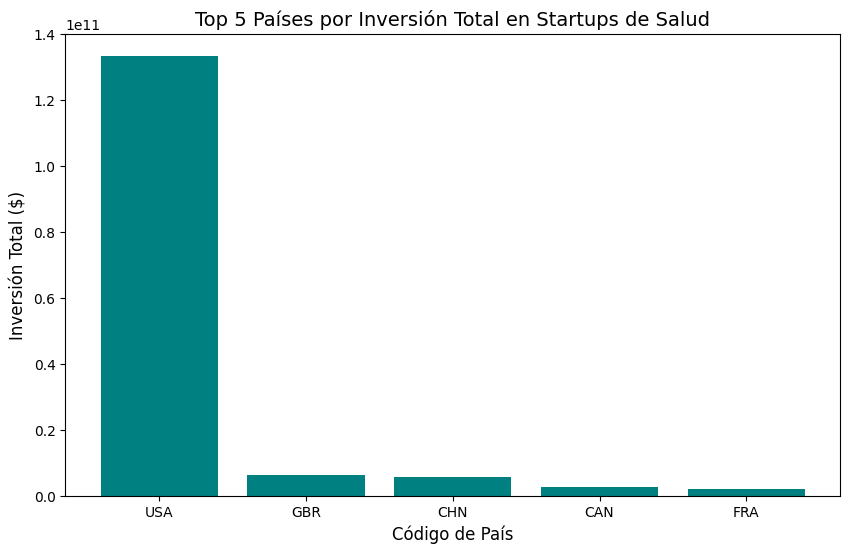

In [ ]:
inversion_por_pais = df_salud.groupby('country_code')['funding_total_usd'].sum()

top_5_paises = inversion_por_pais.sort_values(ascending=False).head(5)

print(top_5_paises)

plt.figure(figsize=(10, 6))
plt.bar(top_5_paises.index, top_5_paises.values, color='teal')
plt.title('Top 5 Países por Inversión Total en Startups de Salud', fontsize=14)
plt.xlabel('Código de País', fontsize=12)
plt.ylabel('Inversión Total ($)', fontsize=12)
plt.show()

El gráfico de barras geográfico es concluyente: Estados Unidos ejerce una hegemonía absoluta, absorbiendo casi la totalidad de la liquidez mundial en salud. Este insight indica que cualquier startup biomédica con ambiciones globales de financiación terminará gravitando hacia el mercado estadounidense.

# 9. Biotech vs Health Care
Como ingenieros biomédicos, hipotetizamos que las startups de biotecnología pura requieren una inyección de capital significativamente mayor debido a los altísimos costes de la I+D y los ensayos clínicos, en comparación con empresas de dispositivos o software médico tradicional. Crearemos una regla de clasificación para segmentar nuestro dataframe en estos dos grandes bloques y calcularemos la media de financiación de cada uno para confirmar o desmentir esta hipótesis con datos empíricos.

--- COSTE MEDIO DE DESARROLLO POR NICHO ---
nicho_principal
Biotech (I+D / Farma)         $28,909,143.20
Health/Medical Tradicional    $17,171,699.26
Name: funding_total_usd, dtype: object




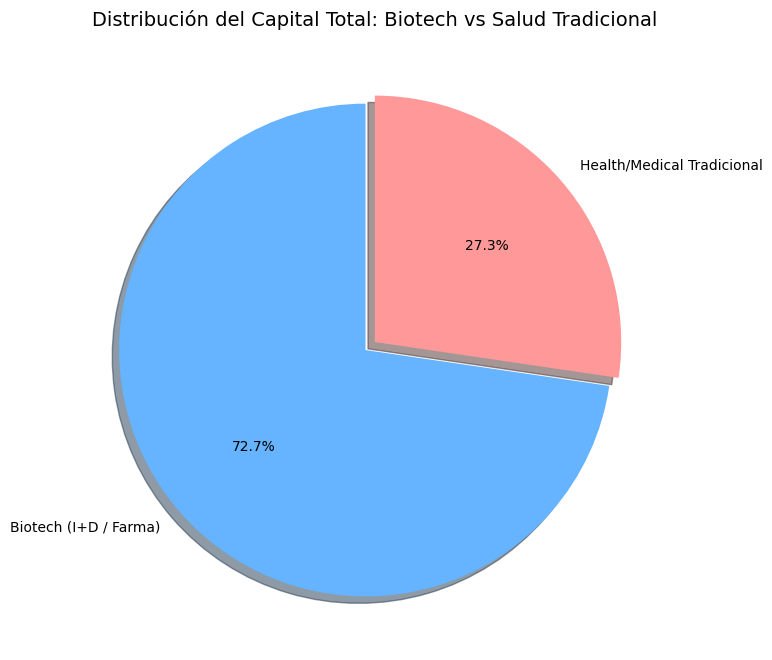

In [ ]:
df_salud['nicho_principal'] = 'Health/Medical Tradicional'

mascara_biotech_pura = df_salud['category_list'].str.contains('Biotechnology')
df_salud.loc[mascara_biotech_pura, 'nicho_principal'] = 'Biotech (I+D / Farma)'

comparativa_costes_medios = df_salud.groupby('nicho_principal')['funding_total_usd'].mean()

print("--- COSTE MEDIO DE DESARROLLO POR NICHO ---")
print(comparativa_costes_medios.map('${:,.2f}'.format))
print("\n")

capital_total_nicho = df_salud.groupby('nicho_principal')['funding_total_usd'].sum()

plt.figure(figsize=(8, 8))
plt.pie(capital_total_nicho.values,
        labels=capital_total_nicho.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#66b3ff', '#ff9999'],
        explode=(0.05, 0),
        shadow=True)
plt.title('Distribución del Capital Total: Biotech vs Salud Tradicional', fontsize=14)
plt.show()

La visualización sectorial validó nuestra hipótesis estructural: la Biotecnología consume una proporción de capital drásticamente mayor. Los altísimos costes de I+D, patentes y ensayos clínicos exigen inyecciones financieras que superan ampliamente a las del software o los servicios médicos tradicionales.

# 10. Análisis de Éxito (Salud vs. Mercado Global)
Para darle contexto a nuestros datos, hemos calculado qué porcentaje de startups médicas logran salir a bolsa y lo hemos comparado matemáticamente con el éxito del resto de industrias globales. Esto nos permite demostrar con datos si hemos elegido un sector rentable o demasiado arriesgado.

In [ ]:
total_salud = len(df_salud)
ipo_salud = len(df_salud[df_salud['status'] == 'ipo'])
porcentaje_exito_salud = (ipo_salud / total_salud) * 100

df_resto = df[~df['category_list'].str.contains('Biotechnology|Health Care|Medical', na=False)]
total_resto = len(df_resto)
ipo_resto = len(df_resto[df_resto['status'] == 'ipo'])
porcentaje_exito_resto = (ipo_resto / total_resto) * 100

print(f"Éxito (IPO) en Sector Salud: {porcentaje_exito_salud:.2f}%")
print(f"Éxito (IPO) en Resto del Mercado: {porcentaje_exito_resto:.2f}%")

Éxito (IPO) en Sector Salud: 7.46%
Éxito (IPO) en Resto del Mercado: 1.64%


Cruzar la tasa de éxito (IPO) del sector salud contra el mercado global nos dio el contexto definitivo. Este benchmark nos demuestra matemáticamente si asumir la enorme barrera de entrada regulatoria y financiera de la medicina compensa frente a invertir en industrias más generalistas.

# Ejercicio 11: El Reloj de la Innovación y Anomalías Temporales
Hemos calculado los días que pasan desde que se funda una empresa hasta que recibe su primer cheque. Durante el análisis, detectamos "anomalías temporales" con valores negativos. Esta reflexión es clave: en el ecosistema real, muchas startups ya tienen pactada su financiación (rondas pre-salida) mucho antes de constituirse legalmente o hacerse públicas. Para no corromper nuestra estadística con estos datos, hemos filtrado dichos valores y los hemos convertido en nulos (`NaN`).

In [ ]:
df_salud['dias_hasta_inversion'] = (df_salud['first_funding_at'] - df_salud['founded_at']).dt.days

mascara_negativos = df_salud['dias_hasta_inversion'] < 0
df_salud.loc[mascara_negativos, 'dias_hasta_inversion'] = np.nan

print(df_salud[['name', 'dias_hasta_inversion']].dropna().head())

                      name  dias_hasta_inversion
6   Ondine Biomedical Inc.                4636.0
30                   Redox                 145.0
40            10X Genomics                1107.0
41        10X Technologies                 311.0
53                121nexus                 122.0


Al observar los primeros resultados validados, constatamos una enorme dispersión en el "reloj de la innovación". Mientras empresas como *121nexus* o *Redox* levantan su primera ronda en apenas unos meses (122-145 días), casos como *Ondine Biomedical* operaron durante más de 12 años (4.636 días) antes de recibir inversión externa. Esto nos demuestra que el ecosistema biomédico no sigue un ciclo temporal estándar: aquí conviven modelos altamente ágiles (probablemente salud digital o software) junto a proyectos de investigación profunda que sobreviven mediante subvenciones o entornos universitarios durante años antes de dar el salto al mercado de capital riesgo.

# Ejercicio 12: Evolución Histórica de la Biotecnología
Queremos comprobar empíricamente si la fundación de empresas biomédicas ha experimentado un crecimiento acelerado en las últimas décadas. Extraeremos el año de la fecha de fundación, agruparemos el dataframe por este nuevo valor cronológico y utilizaremos `.sort_index()` para mantener la línea de tiempo ordenada, observando la tendencia de nacimientos recientes.

In [ ]:
df_salud['año_fundacion'] = df_salud['founded_at'].dt.year

nacimientos_por_año = df_salud.groupby('año_fundacion').size()

nacimientos_recientes = nacimientos_por_año.sort_index(ascending=False)

print(nacimientos_recientes.head(10))

año_fundacion
2016.0      1
2015.0     85
2014.0    308
2013.0    447
2012.0    455
2011.0    431
2010.0    412
2009.0    374
2008.0    325
2007.0    341
dtype: int64


La distribución histórica revela un patrón fascinante: detectamos un claro 'boom' de creación de empresas entre 2010 y 2013 (alcanzando el pico absoluto en 2012 con 455 fundaciones). Sin embargo, observamos una caída drástica en los registros en 2014 y 2015. Este hallazgo nos obliga a pensar con mentalidad de negocio: o bien el mercado sufrió una fuerte corrección tras el auge inicial, o nos enfrentamos a estas empresas aún no eran conocidas ni habían levantado inversión para ser registradas.

# Ejercicio 13: Eficiencia de Capital y Visualización de Dispersión
Crearemos una nueva métrica financiera clave: el 'Ticket Medio por Ronda', dividiendo el capital total entre el número de inyecciones financieras de cada startup. Para evitar distorsiones matemáticas (como divisiones por cero), filtraremos previamente aquellas empresas que tengan al menos una ronda válida registrada. Además, generaremos un gráfico de dispersión (Scatter Plot) para visualizar la relación entre las rondas y el capital levantado, lo que nos permitirá localizar inmediatamente a los 'Outliers' o anomalías del ecosistema.

--- TOP 3 STARTUPS CON MAYOR TICKET MEDIO POR RONDA ---
                  name ticket_medio_por_ronda  funding_rounds
12238            COFCO      $3,200,000,000.00               1
9831        Carestream      $2,400,000,000.00               1
9701   Cardinal Health      $1,500,000,000.00               1




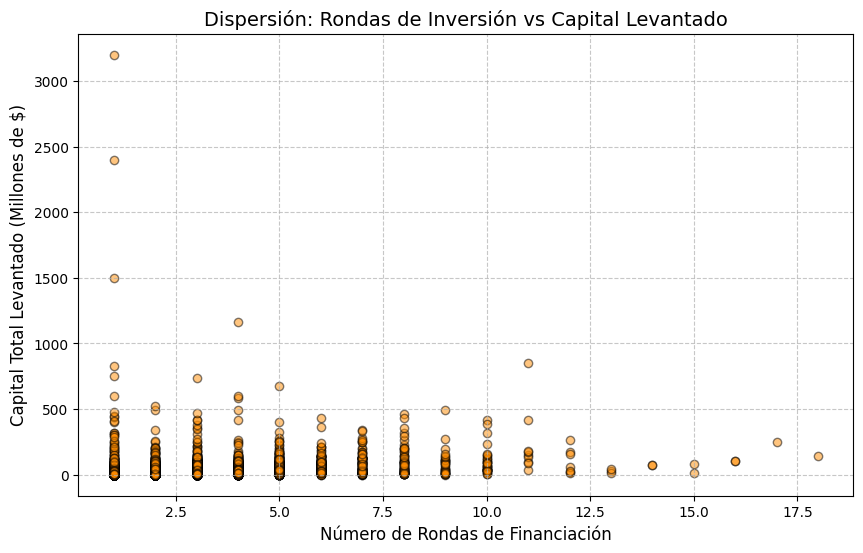

In [ ]:
mascara_rondas_validas = df_salud['funding_rounds'] > 0
df_salud.loc[mascara_rondas_validas, 'ticket_medio_por_ronda'] = df_salud['funding_total_usd'] / df_salud['funding_rounds']

top_3 = df_salud[['name', 'ticket_medio_por_ronda', 'funding_rounds']].sort_values(by='ticket_medio_por_ronda', ascending=False).head(3).copy()
top_3['ticket_medio_por_ronda'] = top_3['ticket_medio_por_ronda'].map('${:,.2f}'.format)

print("--- TOP 3 STARTUPS CON MAYOR TICKET MEDIO POR RONDA ---")
print(top_3)
print("\n")

capital_en_millones = df_salud['funding_total_usd'] / 1000000

plt.figure(figsize=(10, 6))
plt.scatter(df_salud['funding_rounds'], capital_en_millones, alpha=0.5, color='darkorange', edgecolor='black')
plt.title('Dispersión: Rondas de Inversión vs Capital Levantado', fontsize=14)
plt.xlabel('Número de Rondas de Financiación', fontsize=12)
plt.ylabel('Capital Total Levantado (Millones de $)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Al cruzar las rondas con el capital en el gráfico de dispersión, la métrica "Ticket Medio por Ronda" nos permitió identificar inmediatamente a las empresas hiper-eficientes. Visualizar los datos en millones de dólares facilitó separar visualmente a los auténticos *outliers* financieros del resto del mercado.

# 14. Identificación del Unicornio y Camino a la IPO
En este paso, aplicamos una búsqueda de máximos para localizar a la empresa con más fondos de todo el ecosistema (nuestro "Unicornio"). También hemos calculado, iterando con un bucle, la media de rondas de inversión que exige el mercado antes de que una startup de salud logre salir a bolsa.

In [ ]:
max_inversion = df_salud['funding_total_usd'].max()

mascara_max = df_salud['funding_total_usd'] == max_inversion
unicornio = df_salud[mascara_max]

print(unicornio[['name', 'funding_total_usd', 'country_code']])
print("\n")

df_ipo = df_salud[df_salud['status'] == 'ipo']
lista_rondas = df_ipo['funding_rounds'].tolist()

suma_rondas = 0
contador = 0

for rondas in lista_rondas:
    suma_rondas = suma_rondas + rondas
    contador = contador + 1

if contador > 0:
    media_rondas = suma_rondas / contador
else:
    media_rondas = 0

print(media_rondas)

        name  funding_total_usd country_code
12238  COFCO       3.200000e+09          CHN


3.414383561643836


Localizar al líder absoluto de captación nos fija el techo financiero del ecosistema. Complementariamente, calcular la media de rondas necesarias para una IPO nos proporciona una hoja de ruta empírica sobre cuántas fases de dilución deben soportar los fundadores antes de lograr salir a bolsa.

# 15. Creación del "Gold Dataset" para SQL
Para finalizar nuestro pipeline de datos, prepararemos la información para ser consumida por otros departamentos o integrada en una base de datos relacional (SQL). Filtraremos el dataset para descartar las empresas quebradas, seleccionaremos únicamente las columnas de alto valor analítico y exportaremos el resultado a un nuevo archivo CSV limpio y estructurado, nuestro "Gold Dataset".

In [ ]:
mascara_viable = df_salud['status'].isin(['operating', 'ipo', 'acquired'])

columnas_sql = [
    'name',
    'category_list',
    'funding_total_usd',
    'status',
    'country_code',
    'funding_rounds',
    'dias_hasta_inversion'
]

df_sql = df_salud[mascara_viable][columnas_sql].copy()

df_sql.to_csv('startups_salud_gold.csv', index=False)

print(df_sql.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7359 entries, 6 to 66361
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  7359 non-null   object 
 1   category_list         7359 non-null   object 
 2   funding_total_usd     6601 non-null   float64
 3   status                7359 non-null   object 
 4   country_code          7016 non-null   object 
 5   funding_rounds        7359 non-null   int64  
 6   dias_hasta_inversion  5176 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 459.9+ KB
None


Seleccionar exclusivamente las empresas viables y exportarlas marca el éxito del pipeline. Este paso final garantiza que nuestro esfuerzo de limpieza, validación y rigor analítico se traduzca en un producto de datos (`startups_salud_gold.csv`) directamente operable por equipos de Inteligencia de Negocio.